# 01 – EDA: Sepsis vs AKI cohorts

Exploratory analysis of MIMIC-III diagnoses (sepsis vs AKI) and descriptive figures for
the final cohort. Supporting/exploratory — not required to reproduce the model results.

**Run after notebooks 05, 06 and 09b** (uses hourly_vitals.csv,
modelling_cohort_sepsis_mortality.csv, text_hourly_cls_mbert.npz), plus raw MIMIC tables
(DIAGNOSES_ICD, D_ICD_DIAGNOSES, ICUSTAYS).

**Produces:** fig_outcome_dist.png (Fig 4.1), fig_vitals_by_outcome.png (Fig 4.2),
fig_missingness.png (Fig 4.3), fig_note_sparsity.png (Fig 4.4).

MIMIC-III data not included (PhysioNet DUA); see README. Patient-row outputs cleared.

In [6]:
# --- Setup ---
import os

try:
    from config import DATA_DIR
except ImportError:
    DATA_DIR = os.environ.get("ERP_DATA_DIR", "./data")

def data_path(name):
    return os.path.join(DATA_DIR, name)

import pandas as pd
import numpy as np

In [7]:
diagnoses = pd.read_csv(
    data_path("DIAGNOSES_ICD.csv")
)

d_icd = pd.read_csv(
    data_path("D_ICD_DIAGNOSES.csv")
)

In [ ]:
diagnoses.head()

In [ ]:
d_icd.head()

In [ ]:
diagnoses.shape

In [ ]:
d_icd.shape

In [ ]:
diagnoses.info()

In [ ]:
d_icd.info()

In [ ]:
diagnoses["SUBJECT_ID"].nunique()

In [ ]:
diagnoses["HADM_ID"].nunique()

In [ ]:
diagnoses["ICD9_CODE"].nunique()

In [ ]:
sepsis = d_icd[
    d_icd["LONG_TITLE"].str.contains(
        "sepsis|septic",
        case=False,
        na=False
    )
]

sepsis

In [ ]:
aki = d_icd[
    d_icd["LONG_TITLE"].str.contains(
        "acute kidney|acute renal",
        case=False,
        na=False
    )
]

aki

In [19]:
core_codes = [
    "99591",
    "99592",
    "78552"
]

In [ ]:
diagnoses[
    diagnoses["ICD9_CODE"].isin(core_codes)
]

In [21]:
# 1. Sepsis-related codes in the ICD dictionary
sepsis_dict = d_icd[
    d_icd["LONG_TITLE"].str.contains(
        "sepsis|septic",
        case=False,
        na=False
    )
]

# 2. Core sepsis ICD-9 codes
sepsis_codes = ["99591", "99592", "78552"]

# 3. Select sepsis records from the diagnosis table
sepsis_cases = diagnoses[
    diagnoses["ICD9_CODE"].isin(sepsis_codes)
].copy()

# 4. Inspect results
print("Diagnosis records:", len(sepsis_cases))
print("Unique patients:", sepsis_cases["SUBJECT_ID"].nunique())
print("Unique admissions:", sepsis_cases["HADM_ID"].nunique())

sepsis_cases.head()

Diagnosis records: 7770
Unique patients: 4689
Unique admissions: 5325


,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
87,1547,117,164853,16.0,99592
144,1604,124,138376,6.0,99592
276,505,64,172056,3.0,99591
450,679,85,112077,18.0,99591
738,131,21,111970,2.0,78552


In [22]:
aki_codes = ["5845", "5846", "5847", "5848", "5849"]

aki_cases = diagnoses[
    diagnoses["ICD9_CODE"].isin(aki_codes)
].copy()

print("Diagnosis records:", len(aki_cases))
print("Unique patients:", aki_cases["SUBJECT_ID"].nunique())
print("Unique admissions:", aki_cases["HADM_ID"].nunique())

aki_cases.head()

Diagnosis records: 11467
Unique patients: 9536
Unique admissions: 11422


,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
46,1506,115,114585,5.0,5845
75,1535,117,164853,4.0,5849
125,1585,124,134369,2.0,5849
147,1607,124,138376,9.0,5849
316,545,68,108329,5.0,5849


In [ ]:
comparison = pd.DataFrame({
    "Disease": ["Sepsis", "AKI"],
    "Diagnosis_records": [
        len(sepsis_cases),
        len(aki_cases)
    ],
    "Unique_patients": [
        sepsis_cases["SUBJECT_ID"].nunique(),
        aki_cases["SUBJECT_ID"].nunique()
    ],
    "Unique_admissions": [
        sepsis_cases["HADM_ID"].nunique(),
        aki_cases["HADM_ID"].nunique()
    ]
})

comparison

In [ ]:
total_admissions = diagnoses["HADM_ID"].nunique()

comparison["Admission_prevalence"] = (
    comparison["Unique_admissions"] / total_admissions
)

comparison

In [25]:
comparison["Admission_prevalence_percent"] = (
    comparison["Admission_prevalence"] * 100
).round(2)

comparison

,Disease,Diagnosis_records,Unique_patients,Unique_admissions,Admission_prevalence,Admission_prevalence_percent
0,Sepsis,7770,4689,5325,0.090291,9.03
1,AKI,11467,9536,11422,0.193672,19.37


In [26]:
sepsis_hadm = set(sepsis_cases["HADM_ID"])
aki_hadm = set(aki_cases["HADM_ID"])

overlap_hadm = sepsis_hadm.intersection(aki_hadm)

print("Admissions with both Sepsis and AKI:", len(overlap_hadm))

Admissions with both Sepsis and AKI: 2982


In [27]:
print(
    "Percentage of Sepsis admissions also diagnosed with AKI:",
    round(len(overlap_hadm) / len(sepsis_hadm) * 100, 2),
    "%"
)

print(
    "Percentage of AKI admissions also diagnosed with Sepsis:",
    round(len(overlap_hadm) / len(aki_hadm) * 100, 2),
    "%"
)

Percentage of Sepsis admissions also diagnosed with AKI: 56.0 %
Percentage of AKI admissions also diagnosed with Sepsis: 26.11 %


### Disease Selection

An initial exploratory analysis was conducted to compare Sepsis and AKI cohorts.

AKI had 11,422 admissions (19.37%), while Sepsis had 5,325 admissions (9.03%). A substantial overlap was observed between the two diseases, with 56% of Sepsis admissions also diagnosed with AKI.


In [28]:
icustays = pd.read_csv(
    data_path("ICUSTAYS.csv.gz")
)

In [ ]:
icustays.head()

In [ ]:
icustays.shape

In [ ]:
icustays.info()

In [ ]:
icustays.columns

In [33]:
sepsis_icu = sepsis_cases.merge(
    icustays,
    on=["SUBJECT_ID", "HADM_ID"],
    how="inner"
)

print("Sepsis ICU records:", len(sepsis_icu))
print("Unique ICU stays:", sepsis_icu["ICUSTAY_ID"].nunique())

Sepsis ICU records: 8900
Unique ICU stays: 6137


In [34]:
aki_icu = aki_cases.merge(
    icustays,
    on=["SUBJECT_ID", "HADM_ID"],
    how="inner"
)

print("AKI ICU records:", len(aki_icu))
print("Unique ICU stays:", aki_icu["ICUSTAY_ID"].nunique())

AKI ICU records: 12936
Unique ICU stays: 12879


In [35]:
comparison_icu = pd.DataFrame({
    "Disease": ["Sepsis", "AKI"],
    "ICU_stays": [
        sepsis_icu["ICUSTAY_ID"].nunique(),
        aki_icu["ICUSTAY_ID"].nunique()
    ]
})

comparison_icu

,Disease,ICU_stays
0,Sepsis,6137
1,AKI,12879


In [36]:
# ===== Shared preparation for the EDA figures below =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"     # match the serif body font
# BASE handled via DATA_DIR / data_path()

cohort = pd.read_csv(data_path("modelling_cohort_sepsis_mortality.csv"))   # contains mortality_after_24h
vitals = pd.read_csv(data_path("hourly_vitals.csv"))                        # hourly long-format table

VITAL_COLS = ["heart_rate","sbp","dbp","map","resp_rate","temperature","spo2",
              "fio2","glucose","ph","gcs_eye","gcs_motor","gcs_total","gcs_verbal",
              "weight","height"]

lab = cohort[["ICUSTAY_ID","mortality_after_24h"]].drop_duplicates()
# keep only modelling-cohort stays and attach the label to the hourly data
v = vitals[vitals["ICUSTAY_ID"].isin(set(lab["ICUSTAY_ID"]))].merge(lab, on="ICUSTAY_ID", how="left")
print("stays:", v["ICUSTAY_ID"].nunique(), "| rows:", len(v))

stays: 10068 | rows: 241632


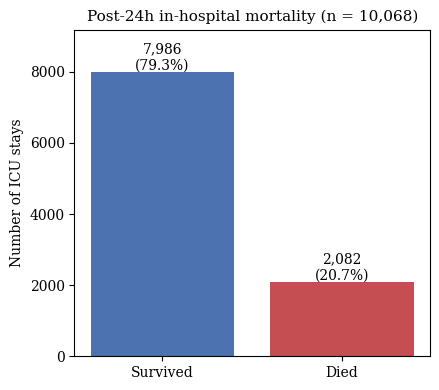

In [37]:
# ===== Figure: outcome distribution =====
counts = lab["mortality_after_24h"].value_counts().sort_index()  # 0 = survived, 1 = died
n0, n1 = int(counts.get(0,0)), int(counts.get(1,0)); N=n0+n1

fig, ax = plt.subplots(figsize=(4.5,4))
bars = ax.bar(["Survived","Died"], [n0,n1], color=["#4c72b0","#c44e52"])
for b,c in zip(bars,[n0,n1]):
    ax.text(b.get_x()+b.get_width()/2, c, f"{c:,}\n({c/N:.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of ICU stays"); ax.set_ylim(0, n0*1.15)
ax.set_title("Post-24h in-hospital mortality (n = {:,})".format(N), fontsize=11)
plt.tight_layout(); plt.savefig("fig_outcome_dist.png", dpi=300, bbox_inches="tight"); plt.show()

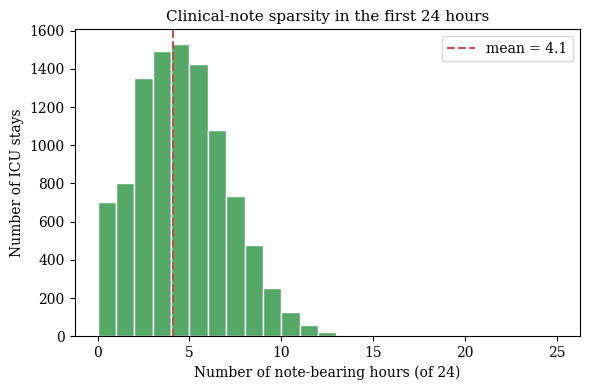

mean note-hours: 4.1 | stays with 0 notes: 705


In [38]:
# ===== Figure: distribution of note-bearing hours =====
tz = np.load(data_path("text_hourly_cls_mbert.npz"), allow_pickle=True)
has_note = tz["has_note"]                    # shape (n_stays, 24), values 0/1
notes_per_stay = has_note.sum(axis=1)        # number of note-bearing hours per stay

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(notes_per_stay, bins=range(0,26), color="#55a868", edgecolor="white")
ax.axvline(notes_per_stay.mean(), color="#c44e52", ls="--", lw=1.5,
           label=f"mean = {notes_per_stay.mean():.1f}")
ax.set_xlabel("Number of note-bearing hours (of 24)")
ax.set_ylabel("Number of ICU stays"); ax.legend()
ax.set_title("Clinical-note sparsity in the first 24 hours", fontsize=11)
plt.tight_layout(); plt.savefig("fig_note_sparsity.png", dpi=300, bbox_inches="tight"); plt.show()

print("mean note-hours:", round(notes_per_stay.mean(),2),
      "| stays with 0 notes:", int((notes_per_stay==0).sum()))

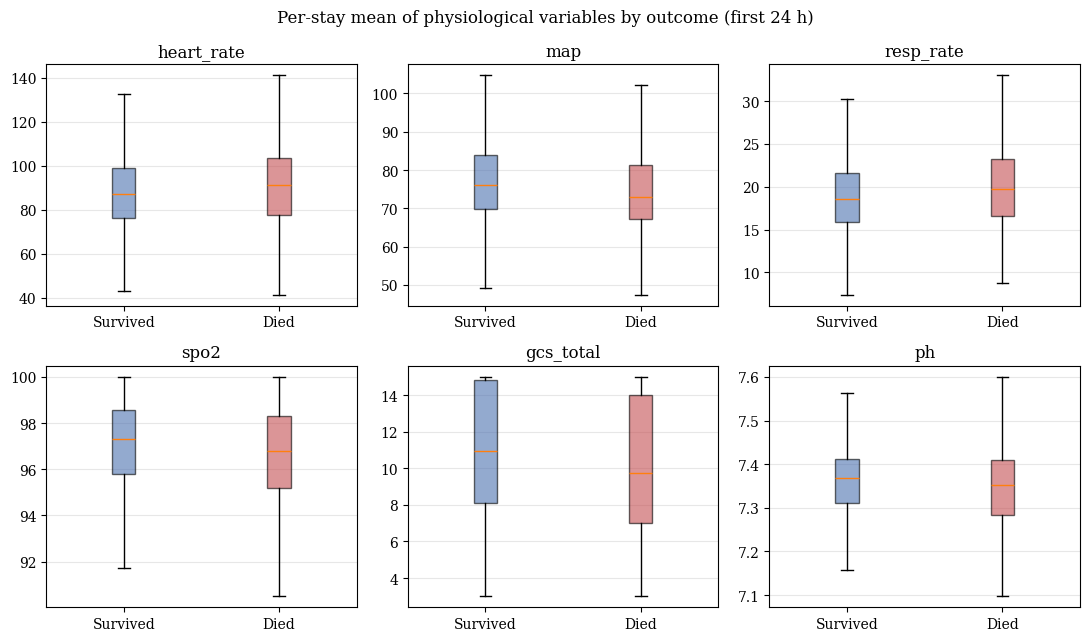

In [39]:
# ===== Figure: physiological variables, survived vs died =====
sel = ["heart_rate","map","resp_rate","spo2","gcs_total","ph"]   # six representative variables
# per-stay 24h mean of each variable
per_stay = v.groupby(["ICUSTAY_ID","mortality_after_24h"])[sel].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(11,6.5))
for ax, col in zip(axes.ravel(), sel):
    d0 = per_stay.loc[per_stay["mortality_after_24h"]==0, col].dropna()
    d1 = per_stay.loc[per_stay["mortality_after_24h"]==1, col].dropna()
    bp = ax.boxplot([d0,d1], tick_labels=["Survived","Died"], showfliers=False, patch_artist=True)
    for patch,c in zip(bp["boxes"], ["#4c72b0","#c44e52"]): patch.set_facecolor(c); patch.set_alpha(.6)
    ax.set_title(col); ax.grid(alpha=.3, axis="y")
fig.suptitle("Per-stay mean of physiological variables by outcome (first 24 h)", fontsize=12)
plt.tight_layout(); plt.savefig("fig_vitals_by_outcome.png", dpi=300, bbox_inches="tight"); plt.show()

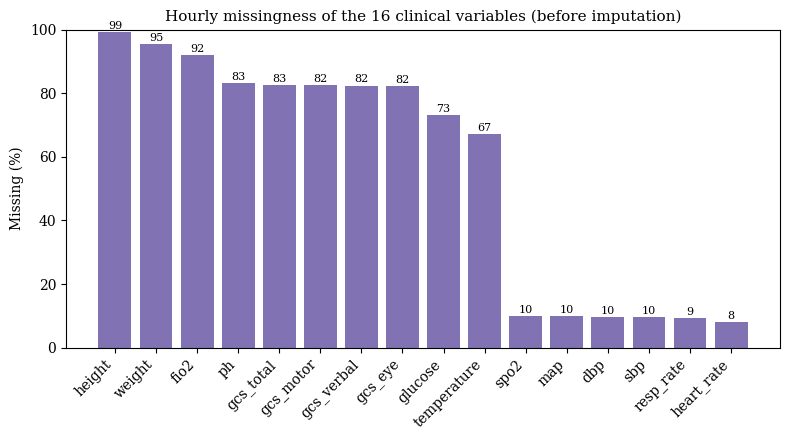

In [40]:
# ===== Figure: missingness bar chart =====
mask_cols = [c+"_observed" for c in VITAL_COLS]
have = [c for c in mask_cols if c in v.columns]
miss = (1 - v[have].mean()).sort_values(ascending=False) * 100   # missing percentage per variable
names = [c.replace("_observed","") for c in miss.index]

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(names, miss.values, color="#8172b3")
ax.set_ylabel("Missing (%)"); ax.set_ylim(0,100)
ax.set_title("Hourly missingness of the 16 clinical variables (before imputation)", fontsize=11)
plt.xticks(rotation=45, ha="right")
for i,val in enumerate(miss.values): ax.text(i, val+1, f"{val:.0f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("fig_missingness.png", dpi=300, bbox_inches="tight"); plt.show()